In [2]:

import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import json
import pandas as pd

from utils.config import Configuration, load_config


subject = 2
mask_value = 7

# 1. Daten: X (n×p), f (n,)
X = np.load(f"data/mds/mds_dir_stan_data/subj_{subject:02d}/subj_{subject:02d}/mask_{mask_value}_single_sample_0_both_mds.npy")  

metadata = np.load(f"data/rdm/rdm_dir_stan_data/subj_{subject:02d}/subj_{subject:02d}/metadata.npy")
animate_labels = pd.read_excel(f"data/labels/subj_{subject:02d}/animate_nonface/animate_non_face_final.xlsx")
face_labels = pd.read_excel(f"data/labels/subj_{subject:02d}/faces/faces_final.xlsx")

animate_labels_cocoIds = [int(x) for x in animate_labels["cocoId"].tolist()]
face_labels_cocoIds = [int(x) for x in face_labels["cocoId"].tolist()]


labels = []
for metadata_entry in metadata:
    metadata_coco = int(metadata_entry.lstrip("0"))
    if metadata_coco in animate_labels_cocoIds:
        labels.append(1)
    elif metadata_coco in face_labels_cocoIds:
        labels.append(0)
    else:
        raise Exception()

labels = np.array(labels)

face_detection_path = "data/labels/subj_01/face_detection_result.json"
with open(face_detection_path, "r") as f:
    face_detection_results = json.load(f)


filtered_face_detection_results = [x for x in face_detection_results if x["file_name"][:-4] in metadata]

In [3]:
# 2. Distanzmatrix und Ähnlichkeitsmatrix
D = squareform(pdist(X, metric='euclidean'))
# S_ij = 1 wenn gleiche Klasse, sonst 0
S = (labels[:, None] == labels[None, :]).astype(int)

# 3. Beobachtete Teststatistik
mask_within  = np.triu(S==1, k=1)
mask_between = np.triu(S==0, k=1)
mean_within  = D[mask_within].mean()
mean_between = D[mask_between].mean()
T_obs = mean_between - mean_within

# 4. Permutationstest
B = 2000
T_perm = np.empty(B)
for b in range(B):
    y_shuff = np.random.permutation(labels)
    S_b = (y_shuff[:, None] == y_shuff[None, :]).astype(int)
    mw = D[np.triu(S_b==1, k=1)].mean()
    mb = D[np.triu(S_b==0, k=1)].mean()
    T_perm[b] = mb - mw

# 5. p-Wert (einseitig: "zwischen > innerhalb")
p_value = (np.sum(T_perm >= T_obs) + 1) / (B + 1)

print(f"Mean within-class distance:  {mean_within:.4f}")
print(f"Mean between-class distance: {mean_between:.4f}")
print(f"T_obs = between − within = {T_obs:.4f}")
print(f"Permutation p-value:        {p_value:.4f}")

Mean within-class distance:  0.7696
Mean between-class distance: 0.8103
T_obs = between − within = 0.0407
Permutation p-value:        0.0005


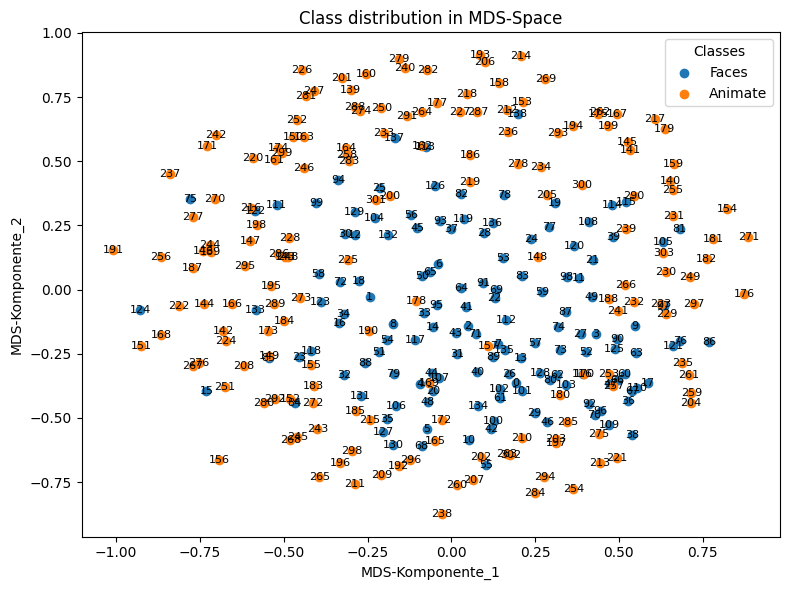

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hier deine Daten laden/einfügen ---
# X: numpy-Array mit den MDS-Koordinaten, Form (n, 2)
# y: numpy-Array mit Binärlabels (0 oder 1), Länge n
# Beispielplatzhalter (entfernen, wenn du echte Daten hast):
# np.random.seed(0)
# X = np.random.randn(180, 2)
# y = np.random.randint(0, 2, size=180)
# ----------------------------------------

# Indizes nach Klasse aufteilen
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]

fig, ax = plt.subplots(figsize=(8, 6))

# Zwei Scatter-Aufrufe, um automatisch zwei Farben aus dem Default-Zyklusschema zu nutzen
ax.scatter(X[idx0, 0], X[idx0, 1], label='Faces')
ax.scatter(X[idx1, 0], X[idx1, 1], label='Animate')

# Beschrifte jeden Punkt mit seiner Index-Nummer
for i in range(X.shape[0]):
    ax.text(X[i, 0], X[i, 1], str(i), fontsize=8, ha='center', va='center')

ax.set_xlabel('MDS-Komponente_1')
ax.set_ylabel('MDS-Komponente_2')
ax.set_title('Class distribution in MDS‐Space')
ax.legend(title='Classes')

plt.tight_layout()
plt.show()


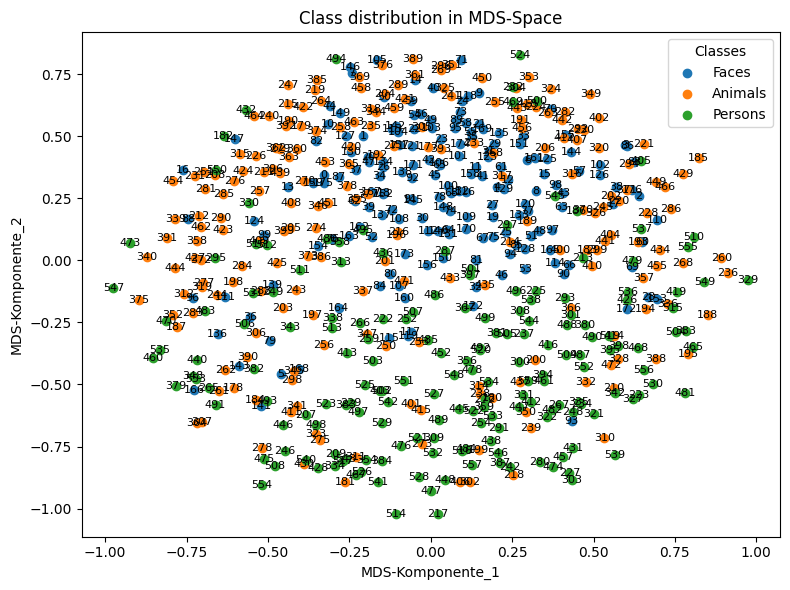

In [5]:
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import json
import pandas as pd

subject = 1
mask_value = 7

# 1. Daten: X (n×p), f (n,)
X = np.load(f"data/mds/mds_3_classes/subj_{subject:02d}/subj_{subject:02d}/mask_{mask_value}_averaged_both_mds.npy")  

metadata = np.load(f"data/rdm/rdm_3_classes/subj_{subject:02d}/subj_{subject:02d}/metadata.npy")
animate_labels = pd.read_excel(f"data/labels/subj_{subject:02d}/animate_nonface/animate_non_face_final.xlsx")

face_labels = pd.read_excel(f"data/labels/subj_{subject:02d}/faces/faces_final.xlsx")

animals_labels_cocoIds = [int(x) for x in animate_labels[animate_labels["label"] == "animals"]["cocoId"].tolist()]
persons_labels_cocoIds = [int(x) for x in animate_labels[animate_labels["label"] == "personen"]["cocoId"].tolist()]

face_labels_cocoIds = [int(x) for x in face_labels["cocoId"].tolist()]


labels = []
for metadata_entry in metadata:
    metadata_coco = int(metadata_entry.lstrip("0"))
    if metadata_coco in animals_labels_cocoIds:
        labels.append(1)
    elif metadata_coco in persons_labels_cocoIds:
        labels.append(2)
    elif metadata_coco in face_labels_cocoIds:
        labels.append(0)
    else:
        raise Exception()

labels = np.array(labels)

face_detection_path = f"data/labels/subj_{subject:02d}/face_detection_result.json"
with open(face_detection_path, "r") as f:
    face_detection_results = json.load(f)


filtered_face_detection_results = [x for x in face_detection_results if x["file_name"][:-4] in metadata]

# --- Hier deine Daten laden/einfügen ---
# X: numpy-Array mit den MDS-Koordinaten, Form (n, 2)
# y: numpy-Array mit Binärlabels (0 oder 1), Länge n
# Beispielplatzhalter (entfernen, wenn du echte Daten hast):
# np.random.seed(0)
# X = np.random.randn(180, 2)
# y = np.random.randint(0, 2, size=180)
# ----------------------------------------

# Indizes nach Klasse aufteilen
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]
idx2 = np.where(labels == 2)[0]


fig, ax = plt.subplots(figsize=(8, 6))

# Zwei Scatter-Aufrufe, um automatisch zwei Farben aus dem Default-Zyklusschema zu nutzen
ax.scatter(X[idx0, 0], X[idx0, 1], label='Faces')
ax.scatter(X[idx1, 0], X[idx1, 1], label='Animals')
ax.scatter(X[idx2, 0], X[idx2, 1], label='Persons')

# Beschrifte jeden Punkt mit seiner Index-Nummer
for i in range(X.shape[0]):
    ax.text(X[i, 0], X[i, 1], str(i), fontsize=8, ha='center', va='center')

ax.set_xlabel('MDS-Komponente_1')
ax.set_ylabel('MDS-Komponente_2')
ax.set_title('Class distribution in MDS‐Space')
ax.legend(title='Classes')

plt.tight_layout()
plt.show()

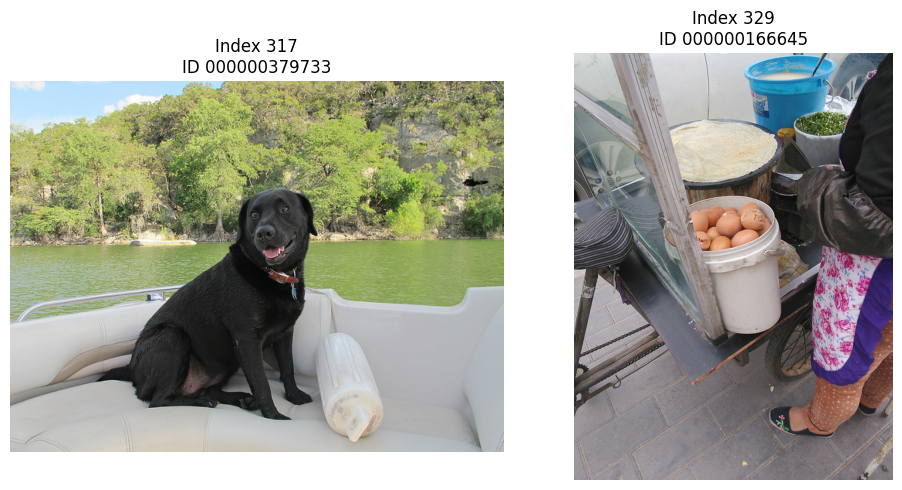

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image_pair(indices, metadata, image_dir, extension='.jpg'):
    """
    Display a pair of images given their indices in the metadata array.

    Args:
        indices    : tuple or list of two integer indices into `metadata`
        metadata   : array-like of file base names (strings, without extension)
        image_dir  : path to directory where the image files are stored
        extension  : file extension (default '.jpg')

    Example:
        # metadata might be loaded like this:
        # metadata = np.load("data/rdm/.../metadata.npy")
        show_image_pair((10, 25), metadata, "data/images", extension=".png")
    """
    # Ensure we have exactly two indices
    if len(indices) != 2:
        raise ValueError("Please provide exactly two indices, e.g. (i, j)")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for ax, idx in zip(axes, indices):
        # infer the base filename from metadata
        base_name = metadata[idx]
        file_name = base_name + extension
        img_path = os.path.join(image_dir, file_name)

        if not os.path.isfile(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        # load and display the image
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Index {idx}\nID {base_name}")

    plt.tight_layout()
    plt.show()


config = load_config("config.yaml")

# Show the images at indices 5 and 42
show_image_pair((317, 329), metadata, config.directories.images_target_dir, extension='.jpg')

In [7]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def permutation_test_knn(
    X: np.ndarray,
    y: np.ndarray,
    n_neighbors: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Führt einen Permutationstest durch, bei dem nur die n_neighbors
    nächsten Nachbarn jedes Punktes im MDS-Space betrachtet werden.

    Args:
      X            : Array der MDS-Koordinaten, Form (n, 2)
      y            : Binäres Label-Array der Länge n (0/1)
      n_neighbors  : Anzahl der nächsten Nachbarn pro Punkt
      B            : Anzahl der Permutationen
      metric       : Distanzmaß (z.B. 'euclidean')

    Returns:
      dict mit:
        - T_obs        : beobachtete Teststatistik (mean_between - mean_within)
        - p_value      : Permutations‑p‑Wert (einseitig)
        - mean_within  : mittlere Distanz innerhalb gleicher Klasse
        - mean_between : mittlere Distanz zwischen Klassen
        - T_perm       : Array aller permutierten Teststatistiken
    """
    # print(X)
    n = X.shape[0]
    # 1) Distanzmatrix im MDS-Space
    D = squareform(pdist(X, metric=metric))

    # 2) Menge aller Neighbor-Paare (i<j) sammeln
    neighbor_pairs = set()
    for i in range(n):
        # argsort schließt i selbst an Position 0 aus, daher [1:...]
        nearest = np.argsort(D[i])[1 : n_neighbors + 1]
        for j in nearest:
            a, b = sorted((i, j))
            neighbor_pairs.add((a, b))
    pairs = np.array(list(neighbor_pairs))  # Form (M, 2)

    # 3) Beobachtete Abstände & Klassen‑Ähnlichkeit
    dists = D[pairs[:,0], pairs[:,1]]
    same_class = (y[pairs[:,0]] == y[pairs[:,1]])

    mean_within  = dists[same_class].mean()
    mean_between = dists[~same_class].mean()
    T_obs = mean_between - mean_within

    # 4) Permutationstest
    T_perm = np.zeros(B)
    for b in range(B):
        y_shuff = np.random.permutation(y)
        same_b = (y_shuff[pairs[:,0]] == y_shuff[pairs[:,1]])
        mw = dists[same_b].mean()
        mb = dists[~same_b].mean()
        T_perm[b] = mb - mw

    # 5) p-Wert (einseitig: "zwischen > innerhalb")
    p_value = (np.sum(T_perm >= T_obs) + 1) / (B + 1)

    return {
        'T_obs': T_obs,
        'p_value': p_value,
        'mean_within': mean_within,
        'mean_between': mean_between,
        'T_perm': T_perm
    }


# X: dein (n×2)-Array mit MDS-Koordinaten
# y: dein Binär-Label-Array (0/1)

result = permutation_test_knn(
    X,
    labels,
    n_neighbors=5,   # z.B. nur die 15 nächsten Nachbarn
    B=5000            # 5000 Permutationen für mehr Stabilität
)

print("Beobachtetes T_obs       :", result['T_obs'])
print("Mean within-class dist. :", result['mean_within'])
print("Mean between-class dist.:", result['mean_between'])
print("Permutation p-value     :", result['p_value'])


Beobachtetes T_obs       : 0.002078365837938287
Mean within-class dist. : 0.07084239053221293
Mean between-class dist.: 0.07292075637015122
Permutation p-value     : 0.09758048390321936


In [8]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def permutation_test_knn_ratio(
    X: np.ndarray,
    y: np.ndarray,
    n_neighbors: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Permutationstest basierend auf Count-Statistik der N nächsten Nachbarn.

    Für jedes Sample i:
      - Finde die n_neighbors nächsten Nachbarn im MDS-Space.
      - Zähle, wie viele davon die gleiche Klasse haben (same_count).
      - Zähle, wie viele anders sind (diff_count).

    Aggregiere über alle i:
      same_total = Summe aller same_count
      diff_total = Summe aller diff_count
      ratio_obs = same_total / diff_total

    Führe B Permutationen der Labels durch, berechne ratio_perm[b] analog.
    Liefert p-Wert für Einseitigen Test (ratio_perm >= ratio_obs).

    Args:
      X            : MDS-Koordinaten, Array der Form (n, 2)
      y            : Binär-Labels (0/1), Länge n
      n_neighbors  : Anzahl der Nachbarn je Punkt
      B            : Anzahl der Permutationen
      metric       : Distanz-Metrik für pdist (z.B. 'euclidean')

    Returns:
      dict mit folgenden Einträgen:
        - ratio_obs   : beobachtetes Verhältnis same/diff
        - p_value     : Permutations-p-Wert (einseitig)
        - same_total  : absolute Anzahl gleichklassiger Nachbarn
        - diff_total  : absolute Anzahl ungleichklassiger Nachbarn
        - ratio_perm  : Array der permutierten Verhältnisse der Länge B
    """
    n = X.shape[0]
    # 1) Paarweise Distanzen
    D = squareform(pdist(X, metric=metric))

    # 2) Für jedes i seine N nächsten Nachbarn bestimmen
    neighbors = [np.argsort(D[i])[1 : n_neighbors + 1] for i in range(n)]

    # 3) Beobachtete Counts
    same_total = 0
    diff_total = 0
    for i, neigh in enumerate(neighbors):
        same = np.sum(y[neigh] == y[i])
        diff = n_neighbors - same
        # print(f"{i}: {same}\t{diff}")

        same_total += same
        diff_total += diff
    ratio_obs = same_total / diff_total
    # prop_obs = same_total / (n * n_neighbors)

    # 4) Permutationstest
    ratio_perm = np.empty(B)
    for b in range(B):
        y_shuff = np.random.permutation(y)
        st = 0
        dt = 0
        for i, neigh in enumerate(neighbors):
            st += np.sum(y_shuff[neigh] == y_shuff[i])
            dt += n_neighbors - np.sum(y_shuff[neigh] == y_shuff[i])
        ratio_perm[b] = st / dt

    # 5) p-Wert (einseitig: ratio_perm >= ratio_obs)
    p_value = (np.sum(ratio_perm >= ratio_obs) + 1) / (B + 1)

    return {
        'ratio_obs': ratio_obs,
        'p_value': p_value,
        'same_total': same_total,
        'diff_total': diff_total,
        'ratio_perm': ratio_perm
    }


# X = dein (n×2)-Array mit MDS-Koordinaten
# y = dein Binär-Label-Array (0/1)

res = permutation_test_knn_ratio(X, labels, n_neighbors=7, B=1000)
print(f"Beobachtetes Ratio (same/diff): {res['ratio_obs']:.3f}")
print(f"Permutation p-value            : {res['p_value']:.4f}")



Beobachtetes Ratio (same/diff): 1.150
Permutation p-value            : 0.0010


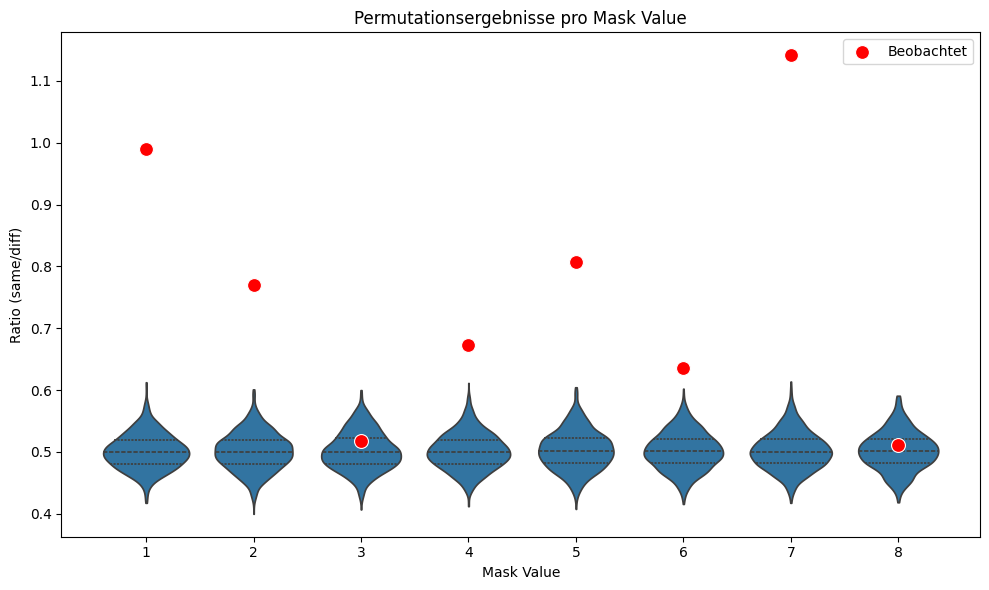

In [9]:
import seaborn as sns

# Parameter
subject = 1
n_neighbors = 4
B = 1000

# Labels & metadata einmal laden
metadata = np.load(f"data/rdm/rdm_3_classes/subj_{subject:02d}/subj_{subject:02d}/metadata.npy")
animate_labels = pd.read_excel(f"data/labels/subj_{subject:02d}/animate_nonface/animate_non_face_final.xlsx")
face_labels    = pd.read_excel(f"data/labels/subj_{subject:02d}/faces/faces_final.xlsx")

animals_ids = [int(x) for x in animate_labels.loc[animate_labels["label"]=="animals","cocoId"]]
persons_ids = [int(x) for x in animate_labels.loc[animate_labels["label"]=="personen","cocoId"]]
faces_ids   = [int(x) for x in face_labels["cocoId"]]

all_perm = []
all_obs  = []

for mask_value in range(1, 9):
    # X laden
    X = np.load(
        f"data/mds/mds_3_classes/subj_{subject:02d}/subj_{subject:02d}"
        f"/mask_{mask_value}_averaged_both_mds.npy"
    )
    # Labels erzeugen
    labels = []
    for entry in metadata:
        cid = int(entry.lstrip("0"))
        if   cid in animals_ids: labels.append(1)
        elif cid in persons_ids: labels.append(2)
        elif cid in faces_ids:   labels.append(0)
        else: raise ValueError(f"Unbekannter cocoId {cid}")
    labels = np.array(labels)

    # Permutationstest einmal pro Maske
    res = permutation_test_knn_ratio(X, labels,
                                     n_neighbors=n_neighbors,
                                     B=B)
    # Permutationswerte sammeln
    for val in res['ratio_perm']:
        all_perm.append({
            'mask_value': mask_value,
            'ratio': val
        })
    # Beobachteten Wert sammeln
    all_obs.append({
        'mask_value': mask_value-1,
        'ratio': res['ratio_obs']
    })

# DataFrames erstellen
df_perm = pd.DataFrame(all_perm)
df_obs  = pd.DataFrame(all_obs)

# Violin-Plot über Mask Values
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='mask_value',
    y='ratio',
    data=df_perm,
    inner='quartile',
    cut=0
)
sns.scatterplot(
    x='mask_value',
    y='ratio',
    data=df_obs,
    color='red',
    s=100,
    zorder=10,
    label='Beobachtet'
)

plt.xlabel('Mask Value')
plt.ylabel('Ratio (same/diff)')
plt.title('Permutationsergebnisse pro Mask Value')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
results_per_class = {}
for k in np.unique(labels):
    y_bin = (labels == k).astype(int)         # Klasse k = 1, Rest = 0
    res_k = permutation_test_knn_ratio(
        X, y_bin, n_neighbors=7, B=1000
    )
    results_per_class[k] = res_k
    print(f"Klasse {k}: ratio={res_k['ratio_obs']:.3f}, p={res_k['p_value']:.4f}")

Klasse 0: ratio=1.411, p=0.0340
Klasse 1: ratio=1.147, p=0.5185
Klasse 2: ratio=1.287, p=0.6114


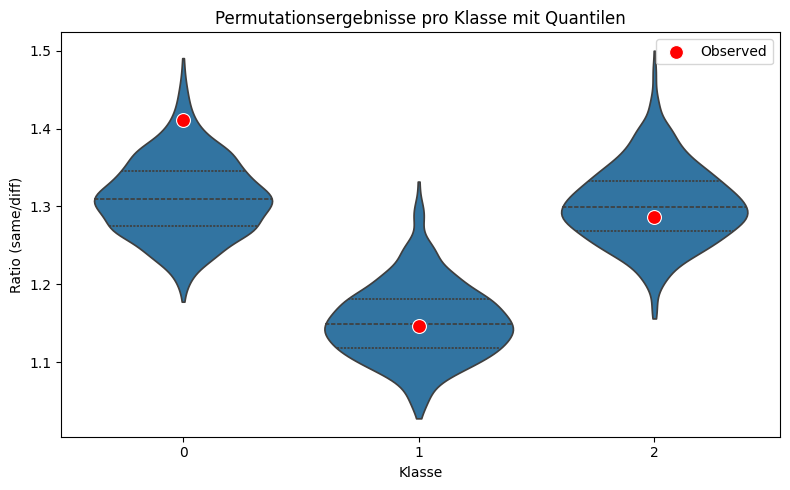

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Dein results_per_class befüllen
# results_per_class = {
#     0: {'ratio_perm': ..., 'ratio_obs': ...},
#     1: {'ratio_perm': ..., 'ratio_obs': ...},
#     2: {'ratio_perm': ..., 'ratio_obs': ...},
# }

# 2) DataFrame für Permutationsverteilungen
perm_rows = []
for cls, vals in results_per_class.items():
    perm_rows += [{'class': cls, 'ratio': r} for r in vals['ratio_perm']]
df_perm = pd.DataFrame(perm_rows)

# 3) DataFrame für beobachtete Werte
obs_df = pd.DataFrame({
    'class': list(results_per_class.keys()),
    'ratio': [results_per_class[k]['ratio_obs'] for k in results_per_class]
})

# 4) Plot
plt.figure(figsize=(8, 5))
sns.violinplot(
    x='class',
    y='ratio',
    data=df_perm,
    inner='quartile',    # zeigt 25%, 50%, 75%-Linien
    cut=0                # keine Ausläufer über den Databereich hinaus
)
sns.scatterplot(
    x='class',
    y='ratio',
    data=obs_df,
    color='red',
    s=100,
    marker='o',
    label='Observed',
    zorder=5
)

plt.xlabel('Klasse')
plt.ylabel('Ratio (same/diff)')
plt.title('Permutationsergebnisse pro Klasse mit Quantilen')
plt.legend()
plt.tight_layout()
plt.show()


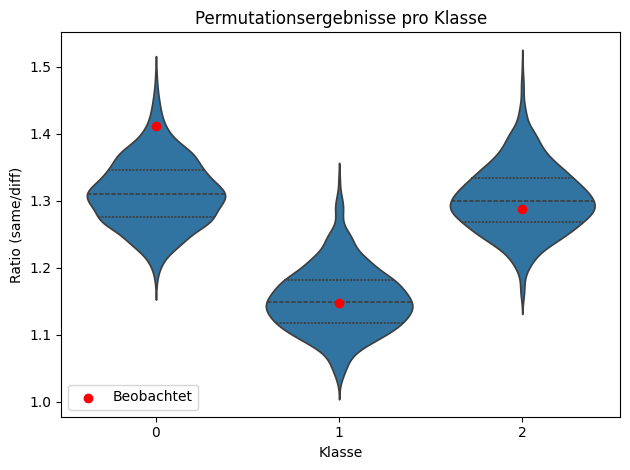

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



# DataFrame für Permutationsdaten aufbauen
perm_rows = []
for cls, vals in results_per_class.items():
    for ratio in vals['ratio_perm']:
        perm_rows.append({'class': cls, 'ratio': ratio})
df_perm = pd.DataFrame(perm_rows)

# DataFrame für beobachtete Werte
obs_df = pd.DataFrame({
    'class': list(results_per_class.keys()),
    'ratio': [results_per_class[k]['ratio_obs'] for k in results_per_class]
})

# Plot mit Seaborn
sns.violinplot(x='class', y='ratio', data=df_perm, inner='quartile')
plt.scatter(x=obs_df['class'], y=obs_df['ratio'], color='red', zorder=10, label='Beobachtet')

plt.xlabel('Klasse')
plt.ylabel('Ratio (same/diff)')
plt.title('Permutationsergebnisse pro Klasse')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def morans_I_permutation(
    X: np.ndarray,
    y: np.ndarray,
    k: int = 10,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Berechnet Global Moran’s I für binäre Labels y mit k‑NN-Gewichten
    und ermittelt seine Signifikanz per Permutationstest.

    Args:
      X      : Array der MDS‑Koordinaten, Form (n, 2) (oder beliebig p‑dimensional)
      y      : Binär‑Labels (0/1), Länge n
      k      : Anzahl der nächsten Nachbarn für die Gewichts‑Matrix W
      B      : Anzahl der Permutationen
      metric : Distanzmaß für pdist (z.B. 'euclidean')

    Returns:
      dict mit:
        - I_obs   : beobachtetes Moran’s I
        - p_value : Permutations‑p‑Wert (einseitig: I_perm ≥ I_obs)
        - I_perm  : Array der permutierten Moran’s I (Länge B)
    """
    n = len(y)
    # 1) Paarweise Distanzen und kNN‑Graph
    D = squareform(pdist(X, metric=metric))
    W = np.zeros((n, n), dtype=int)
    for i in range(n):
        # nächstgelegene k Nachbarn (ohne i selbst)
        nbrs = np.argsort(D[i])[1:k+1]
        W[i, nbrs] = 1
    # symmetrisch machen (ungerichteter Graph)
    W = ((W + W.T) > 0).astype(int)
    S0 = W.sum()

    # 2) Beobachtetes Moran’s I
    y_bar = y.mean()
    num = np.sum(W * (y[:, None] - y_bar) * (y[None, :] - y_bar))
    den = np.sum((y - y_bar) ** 2)
    I_obs = (n / S0) * (num / den)

    # 3) Permutationstest
    I_perm = np.zeros(B)
    for b in range(B):
        y_p = np.random.permutation(y)
        num_p = np.sum(W * (y_p[:, None] - y_bar) * (y_p[None, :] - y_bar))
        I_perm[b] = (n / S0) * (num_p / den)

    # 4) p‑Wert (einseitig)
    p_value = (np.sum(I_perm >= I_obs) + 1) / (B + 1)

    return {
        'I_obs': I_obs,
        'p_value': p_value,
        'I_perm': I_perm
    }

res = morans_I_permutation(X, labels, k=5, B=1000)
print(f"Beobachtetes Ratio (same/diff): {res['I_obs']:.3f}")
print(f"Permutation p-value            : {res['p_value']:.4f}")

Beobachtetes Ratio (same/diff): 0.016
Permutation p-value            : 0.2268


Kurze Übersicht weiterer Verfahren

    Join‑Count‑Statistik

        Graph: k‑NN oder Delaunay‑Triangulation

        Zähle Kanten BB (0–0), WW (1–1) und BW (0–1)

        Permutation der Labels → Nullverteilung für z. B. BB+WW

    Cuzick‑Edwards k‑NN‑Test

        Für jede „Fall“-Probe (Label 1) zähle, wie viele ihrer k NN ebenfalls Fälle sind

        Summe über alle Fälle → Teststatistik

        Permutation der Labels liefert Signifikanz

    Ripley’s K/L‑Funktion (cross‑K)

        Untersuche für verschiedene Radien r, ob Fälle und Kontrollen sich mischen oder clustern

        Vergleich der empirischen K₁₂(r) mit Simulationen randomisierter Labels

    Local Moran’s I / LISA

        Lokale Autokorrelationsstatistik pro Punkt

        Identifikation von „Hot Spots“ und „Cold Spots“

        Ergänzt Global‑Moran um lokale Detailinformation

    Getis‑Ord G*‑Statistik

        Misst Lokalisierte Cluster hoher bzw. niedriger Werte

        Ebenfalls permutativ testbar auf binäre oder kontinuierliche Attribute

In [21]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import json
import pandas as pd


subject_i = 1

# 1. Daten: X (n×p), f (n,)
X = np.load(f"data/mds/mds_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/mask_7_averaged_both_mds.npy")  

metadata = np.load(f"data/rdm/rdm_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/metadata.npy")
animate_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/animate_nonface/animate_non_face_final.xlsx")
face_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/faces/faces_final.xlsx")

animate_labels_cocoIds = [int(x) for x in animate_labels["cocoId"].tolist()]
face_labels_cocoIds = [int(x) for x in face_labels["cocoId"].tolist()]


labels = []
for metadata_entry in metadata:
    metadata_coco = int(metadata_entry.lstrip("0"))
    if metadata_coco in animate_labels_cocoIds:
        labels.append(1)
    elif metadata_coco in face_labels_cocoIds:
        labels.append(0)
    else:
        raise Exception()

labels = np.array(labels)

face_detection_path = f"data/labels/subj_{subject_i:02d}/face_detection_result.json"
with open(face_detection_path, "r") as f:
    face_detection_results = json.load(f)


filtered_face_detection_results = [x for x in face_detection_results if x["file_name"][:-4] in metadata]
for x in filtered_face_detection_results:
    x["cocoId"] = x["file_name"][:-4]




feature_array = []
feature_array_gender = []
feature_array_age = []

for entry in metadata:
    fitting_det_res = [x for x in filtered_face_detection_results if x["cocoId"] == entry][0]
    assert len(fitting_det_res["detection"]) == 1


    feature_array.append(fitting_det_res["detection"][0])
    feature_array_gender.append(fitting_det_res["gender"])
    feature_array_age.append(fitting_det_res["age"])

bboxes = np.array(feature_array)       # shape (N,4)
# (x1, y1) + half the width/height
centers_np = bboxes[:, :2] + (bboxes[:, 2:] - bboxes[:, :2]) / 2

feature_array_gender = np.array(feature_array_gender)
feature_array_age = np.array(feature_array_age)


In [7]:
# filtered_face_detection_results

In [9]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def mantel_test_feature(
    X: np.ndarray,
    feature: np.ndarray,
    B: int = 2000,
    metric: str = 'euclidean'
) -> dict:
    """
    Mantel test: correlation between the distance matrix of MDS coordinates X
    and the distance matrix of an arbitrary feature, using a permutation test.

    Args:
      X       : (n×p) array of MDS coordinates
      feature : array of length n (1D) or shape (n×m) (m feature dimensions)
      B       : number of permutations (default: 2000)
      metric  : distance metric for pdist (default: 'euclidean')

    Returns:
      dict with:
        - r_obs   : observed Spearman correlation
        - p_value : permutation p-value (two-sided)
        - r_perm  : array of permuted correlations (length B)
    """
    X = np.asarray(X)
    feature = np.asarray(feature)

    # Ensure X and feature have the same number of samples
    assert X.shape[0] == feature.shape[0], \
        f"X has {X.shape[0]} rows but feature has {feature.shape[0]} entries."

    # If feature is 1D, reshape to 2D for pdist
    if feature.ndim == 1:
        feature_vals = feature.reshape(-1, 1)
    else:
        feature_vals = feature

    n = X.shape[0]

    # 1) Compute distance matrices
    D_X = squareform(pdist(X,           metric=metric))
    D_F = squareform(pdist(feature_vals, metric=metric))

    # 2) Vectorize the upper triangles (i < j)
    iu    = np.triu_indices(n, k=1)
    d_vec = D_X[iu]
    f_vec = D_F[iu]

    # 3) Compute observed Spearman correlation
    r_obs, _ = spearmanr(d_vec, f_vec)

    # 4) Permutation test
    r_perm = np.empty(B)
    for b in range(B):
        perm = np.random.permutation(n)
        # Get permuted feature distance matrix
        D_F_perm = D_F[perm][:, perm]
        f_p = D_F_perm[iu]
        r_perm[b], _ = spearmanr(d_vec, f_p)

    # 5) Two-sided p-value
    p_value = (np.sum(np.abs(r_perm) >= abs(r_obs)) + 1) / (B + 1)

    return {
        'r_obs': r_obs,
        'p_value': p_value,
        'r_perm': r_perm
    }


In [26]:
res = mantel_test_feature(X, feature_array_age)

In [27]:
res

{'r_obs': 0.04965029277850826,
 'p_value': 0.05747126436781609,
 'r_perm': array([ 0.00956052, -0.02251508, -0.0152338 , ..., -0.00813299,
        -0.01332872,  0.00040692])}

In [2]:
import os
import json
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def mantel_test_feature(X: np.ndarray, feature: np.ndarray, B: int = 2000, metric: str = 'euclidean') -> dict:
    X = np.asarray(X)
    feature = np.asarray(feature)

    assert X.shape[0] == feature.shape[0], "X and feature must have same length"

    if feature.ndim == 1:
        feature_vals = feature.reshape(-1, 1)
    else:
        feature_vals = feature

    n = X.shape[0]

    D_X = squareform(pdist(X, metric=metric))
    D_F = squareform(pdist(feature_vals, metric=metric))

    iu = np.triu_indices(n, k=1)
    d_vec = D_X[iu]
    f_vec = D_F[iu]

    r_obs, _ = spearmanr(d_vec, f_vec)

    r_perm = np.empty(B)
    for b in range(B):
        perm = np.random.permutation(n)
        D_F_perm = D_F[perm][:, perm]
        f_p = D_F_perm[iu]
        r_perm[b], _ = spearmanr(d_vec, f_p)

    p_value = (np.sum(np.abs(r_perm) >= abs(r_obs)) + 1) / (B + 1)

    return {
        'r_obs': r_obs,
        'p_value': p_value,
        'r_perm': r_perm
    }

def run_mantel_test_for_subject(subject_i: int, mask: int = 7, B: int = 2000):
    # Load MDS data
    X = np.load(f"data/mds/mds_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/mask_{mask}_averaged_both_mds.npy")

    # Load metadata and labels
    metadata = np.load(f"data/rdm/rdm_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/metadata.npy")
    animate_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/animate_nonface/animate_non_face_final.xlsx")
    face_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/faces/faces_final.xlsx")

    animate_ids = set(int(x) for x in animate_labels["cocoId"])
    face_ids = set(int(x) for x in face_labels["cocoId"])

    labels = []
    for entry in metadata:
        coco = int(entry.lstrip("0"))
        if coco in animate_ids:
            labels.append(1)
        elif coco in face_ids:
            labels.append(0)
        else:
            raise ValueError(f"Unknown COCO ID: {coco}")

    labels = np.array(labels)

    # Load face detection results and match to metadata
    face_det_path = f"data/labels/subj_{subject_i:02d}/face_detection_result.json"
    with open(face_det_path, "r") as f:
        face_detections = json.load(f)

    filtered = [x for x in face_detections if x["file_name"][:-4] in metadata]
    for x in filtered:
        x["cocoId"] = x["file_name"][:-4]

    centers = []
    eye_coordinates = []
    feature_array_age = []
    
    for entry in metadata:
        match = next(x for x in filtered if x["cocoId"] == entry)
        assert len(match["detection"]) == 1
        bbox = match["detection"][0]
        center = np.array(bbox[:2]) + (np.array(bbox[2:]) - np.array(bbox[:2])) / 2
        centers.append(center)

        feature_array_age.append(match["age"])

        # left eye: index 38
        # right eye: index 88

    centers_np = np.array(centers)
    feature_array_age = np.array(feature_array_age)
    

    features = feature_array_age


    result = mantel_test_feature(X, features, B=B)

    return {
        "subject": subject_i,
        "r_obs": result["r_obs"],
        "p_value": result["p_value"]
    }

# Run for subjects 1–8 and collect results
results = []
for subj in range(1, 9):
    try:
        res = run_mantel_test_for_subject(subj, B=2000, mask=1)
        results.append(res)
        print(f"Subject {subj:02d} → r = {res['r_obs']:.3f}, p = {res['p_value']:.4f}")
    except Exception as e:
        print(f"Subject {subj:02d} failed: {e}")

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("\nFinal Result Table:")
print(df_results.to_string(index=False))


Subject 01 → r = 0.016, p = 0.4818
Subject 02 → r = 0.043, p = 0.0580
Subject 03 → r = -0.005, p = 0.8571
Subject 04 → r = 0.054, p = 0.0580
Subject 05 → r = 0.043, p = 0.0955
Subject 06 → r = 0.024, p = 0.5542
Subject 07 → r = -0.004, p = 0.8311
Subject 08 → r = -0.017, p = 0.5087

Final Result Table:
 subject     r_obs  p_value
       1  0.015580 0.481759
       2  0.043411 0.057971
       3 -0.004594 0.857071
       4  0.054397 0.057971
       5  0.042814 0.095452
       6  0.023638 0.554223
       7 -0.003936 0.831084
       8 -0.017287 0.508746


In [7]:
import os
import json
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def mantel_test_feature(X: np.ndarray, feature: np.ndarray, B: int = 2000, metric: str = 'euclidean') -> dict:
    X = np.asarray(X)
    feature = np.asarray(feature)

    assert X.shape[0] == feature.shape[0], "X and feature must have same length"

    if feature.ndim == 1:
        feature_vals = feature.reshape(-1, 1)
    else:
        feature_vals = feature

    n = X.shape[0]

    D_X = squareform(pdist(X, metric=metric))
    D_F = squareform(pdist(feature_vals, metric=metric))

    iu = np.triu_indices(n, k=1)
    d_vec = D_X[iu]
    f_vec = D_F[iu]

    r_obs, _ = spearmanr(d_vec, f_vec)

    r_perm = np.empty(B)
    for b in range(B):
        perm = np.random.permutation(n)
        D_F_perm = D_F[perm][:, perm]
        f_p = D_F_perm[iu]
        r_perm[b], _ = spearmanr(d_vec, f_p)

    p_value = (np.sum(np.abs(r_perm) >= abs(r_obs)) + 1) / (B + 1)

    return {
        'r_obs': r_obs,
        'p_value': p_value,
        'r_perm': r_perm
    }

def run_mantel_test_for_subject_mask(subject_i: int, mask: int, B: int = 2000) -> dict:
    try:
        X = np.load(f"data/mds/mds_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/mask_{mask}_averaged_both_mds.npy")
        metadata = np.load(f"data/rdm/rdm_stan_data_face_only/subj_{subject_i:02d}/subj_{subject_i:02d}/metadata.npy")
        animate_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/animate_nonface/animate_non_face_final.xlsx")
        face_labels = pd.read_excel(f"data/labels/subj_{subject_i:02d}/faces/faces_final.xlsx")

        animate_ids = set(int(x) for x in animate_labels["cocoId"])
        face_ids = set(int(x) for x in face_labels["cocoId"])

        labels = []
        for entry in metadata:
            coco = int(entry.lstrip("0"))
            if coco in animate_ids:
                labels.append(1)
            elif coco in face_ids:
                labels.append(0)
            else:
                raise ValueError(f"Unknown COCO ID: {coco}")
        labels = np.array(labels)

        face_det_path = f"data/labels/subj_{subject_i:02d}/face_detection_result.json"
        with open(face_det_path, "r") as f:
            face_detections = json.load(f)

        filtered = [x for x in face_detections if x["file_name"][:-4] in metadata]
        for x in filtered:
            x["cocoId"] = x["file_name"][:-4]

        centers = []
        eye_coordinates = []
        feature_array_age = []
        
        for entry in metadata:
            match = next(x for x in filtered if x["cocoId"] == entry)
            assert len(match["detection"]) == 1
            bbox = match["detection"][0]
            center = np.array(bbox[:2]) + (np.array(bbox[2:]) - np.array(bbox[:2])) / 2
            centers.append(center)

            feature_array_age.append(match["age"])

            # left eye: index 38
            # right eye: index 88

        centers_np = np.array(centers)
        feature_array_age = np.array(feature_array_age)
        

        features = centers_np



        result = mantel_test_feature(X, features, B=B)

        return {
            "subject": subject_i,
            "mask": mask,
            "r_obs": result["r_obs"],
            "effect_size": result["r_obs"],  # using r_obs as effect size
            "p_value": result["p_value"]
        }

    except Exception as e:
        print(f"Subject {subject_i:02d}, Mask {mask} failed: {e}")
        return {
            "subject": subject_i,
            "mask": mask,
            "r_obs": np.nan,
            "effect_size": np.nan,
            "p_value": np.nan
        }

# Run over subjects and masks
results = []
for subj in range(1, 9):
    for mask in range(1, 10):
        res = run_mantel_test_for_subject_mask(subj, mask, B=2000)
        results.append(res)
        print(f"Subject {res['subject']:02d}, Mask {res['mask']} → r = {res['r_obs']:.3f}, p = {res['p_value']:.4f}")

# Convert to DataFrame and show summary
df_results = pd.DataFrame(results)
print("\nFinal Result Table:")
print(df_results.to_string(index=False))


Subject 01, Mask 1 → r = 0.093, p = 0.0005
Subject 01, Mask 2 → r = 0.035, p = 0.1349
Subject 01, Mask 3 → r = 0.026, p = 0.1854
Subject 01, Mask 4 → r = 0.019, p = 0.3998
Subject 01, Mask 5 → r = 0.040, p = 0.0795
Subject 01, Mask 6 → r = 0.056, p = 0.0060
Subject 01, Mask 7 → r = 0.089, p = 0.0020
Subject 01, Mask 8 → r = 0.033, p = 0.1074
Subject 01, Mask 9 failed: [Errno 2] No such file or directory: 'data/mds/mds_stan_data_face_only/subj_01/subj_01/mask_9_averaged_both_mds.npy'
Subject 01, Mask 9 → r = nan, p = nan
Subject 02, Mask 1 → r = 0.200, p = 0.0005
Subject 02, Mask 2 → r = 0.006, p = 0.8141
Subject 02, Mask 3 → r = 0.012, p = 0.6072
Subject 02, Mask 4 → r = 0.010, p = 0.6737
Subject 02, Mask 5 → r = 0.080, p = 0.0040
Subject 02, Mask 6 → r = 0.066, p = 0.0075
Subject 02, Mask 7 → r = 0.290, p = 0.0005
Subject 02, Mask 8 failed: [Errno 2] No such file or directory: 'data/mds/mds_stan_data_face_only/subj_02/subj_02/mask_8_averaged_both_mds.npy'
Subject 02, Mask 8 → r = nan,

In [8]:
df_results.to_excel(f"data/mantel_results_face_locations.xlsx")

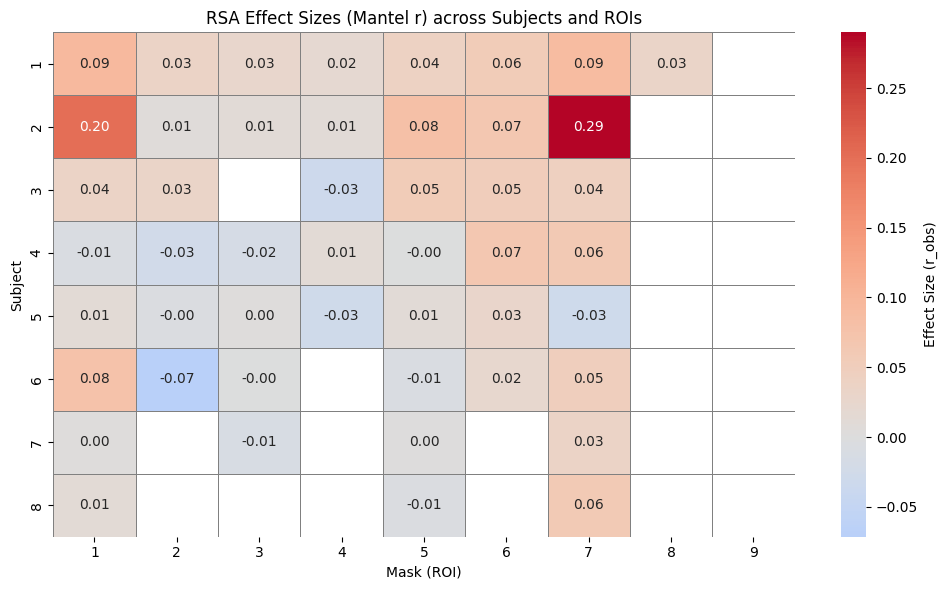

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pivot table: rows = subjects, columns = masks, values = r_obs
heatmap_data = df_results.pivot(index="subject", columns="mask", values="r_obs")

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    mask=heatmap_data.isna(),
    cbar_kws={'label': 'Effect Size (r_obs)'}
)
plt.title("RSA Effect Sizes (Mantel r) across Subjects and ROIs")
plt.xlabel("Mask (ROI)")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()


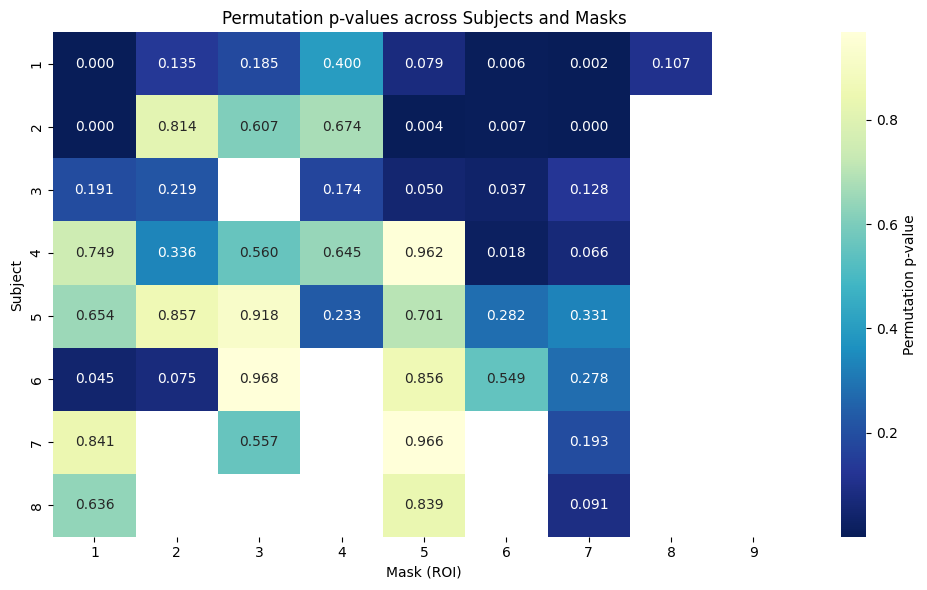

In [10]:
pval_data = df_results.pivot(index="subject", columns="mask", values="p_value")

plt.figure(figsize=(10, 6))
sns.heatmap(
    pval_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu_r",
    mask=pval_data.isna(),
    cbar_kws={'label': 'Permutation p-value'}
)
plt.title("Permutation p-values across Subjects and Masks")
plt.xlabel("Mask (ROI)")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()


In [24]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def mantel_with_local(
    X: np.ndarray,
    feature: np.ndarray,
    B: int = 2000,
    metric: str = 'euclidean',
    N_neighbors: int = None
) -> dict:
    """
    Global Mantel + per-sample local Mantel correlations.

    Args:
      X           : (n×p) MDS coords
      feature     : (n,) or (n×m) feature(s)
      B           : # permutations for global Mantel only
      metric      : pdist metric
      N_neighbors : if int, compute a local Mantel for each point’s N neighbors

    Returns:
      {
        'r_obs'   : global Spearman ρ,
        'p_value' : two‐sided perm p for r_obs,
        'r_perm'  : permuted ρ’s (length B),
        # if N_neighbors is set:
        'r_local' : array (n,) of local ρ’s,
        'delta_r' : r_local – r_obs
      }
    """
    X = np.asarray(X)
    feature = np.asarray(feature)
    n = X.shape[0]
    assert feature.shape[0] == n, "Mismatched sample counts."

    # Global distance matrices
    D_X = squareform(pdist(X, metric=metric))
    feat = feature.reshape(n, -1)
    D_F = squareform(pdist(feat, metric=metric))
    iu = np.triu_indices(n, k=1)

    # 1) Global Mantel
    d_vec, f_vec = D_X[iu], D_F[iu]
    r_obs, _ = spearmanr(d_vec, f_vec)
    r_perm = np.empty(B)
    for b in range(B):
        perm = np.random.permutation(n)
        f_p = D_F[perm][:, perm][iu]
        r_perm[b], _ = spearmanr(d_vec, f_p)
    p_val = (np.sum(np.abs(r_perm) >= abs(r_obs)) + 1) / (B + 1)

    results = {'r_obs': r_obs, 'p_value': p_val, 'r_perm': r_perm}

    # 2) Local Mantel per sample
    if N_neighbors is not None:
        # Precompute neighbor sets
        nbrs = [np.argsort(D_X[i])[1:N_neighbors+1] for i in range(n)]
        r_local = np.zeros(n)
        for i in range(n):
            region = np.concatenate(([i], nbrs[i]))
            # get upper-triangle of the submatrices
            iu_loc = np.triu_indices(len(region), k=1)
            sub_X = D_X[np.ix_(region, region)][iu_loc]
            sub_F = D_F[np.ix_(region, region)][iu_loc]
            r_local[i], _ = spearmanr(sub_X, sub_F)

        results['r_local'] = r_local
        results['delta_r'] = r_local - r_obs

    return results


In [32]:
res = mantel_with_local(X, feature_array, N_neighbors=300)

In [33]:
np.mean(res["r_local"])

np.float64(0.08338257904874281)

In [14]:
from insightface.app import FaceAnalysis
app = FaceAnalysis(name='buffalo_l')  # this is a specific model config
app.prepare(ctx_id=0)
# Then you can inspect app.models['detection'] for architecture


/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.6 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [15]:
print(app.models["detection"].__dict__.keys())
app.models["detection"].model_file

dict_keys(['model_file', 'session', 'taskname', 'center_cache', 'nms_thresh', 'det_thresh', 'input_size', 'input_shape', 'input_name', 'output_names', 'input_mean', 'input_std', 'use_kps', '_anchor_ratio', '_num_anchors', 'fmc', '_feat_stride_fpn'])


'/home/max/.insightface/models/buffalo_l/det_10g.onnx'

In [1]:

import cv2
from onnx2torch import convert
import torch
from insightface.app import FaceAnalysis
import numpy as np

app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0)

onnx_model_path = app.models["detection"].model_file
torch_model = convert(onnx_model_path)

img = cv2.imread("data/images/000000531961.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))

# InsightFace default preprocessing: just convert to float32
img_input = img_resized.astype(np.float32)
img_input = np.transpose(img_input, (2, 0, 1))  # (HWC) → (CHW)
img_input = np.expand_dims(img_input, axis=0)   # Add batch dim
img_input = torch.from_numpy(img_input)

bboxes, kpss = app.models["detection"].detect(img,
                                             metric='default')

/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.6 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/max/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [32]:
bboxes

array([[ 73.773575  , -30.693436  , 423.61682   , 382.85126   ,
          0.50168604]], dtype=float32)